<h1 style='color:blue', align='center'>Mobile Price Classification</h1>

## Import Liabraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Loading of the Dataset

In [2]:
data = pd.read_csv(r'C:\Users\ADMIN\Desktop\Jupyter folder/Downloads/data_mobile_price_range.csv')
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [3]:
print('Rows and Columns of the Data : ',data.shape)

Rows and Columns of the Data :  (2000, 21)


In [4]:
print('Dataset information :\n',data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


## Checking of Missing values

In [6]:
print('Number of Null values under the each column : ',data.isnull().sum())

Number of Null values under the each column :  battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


## Seperate Features and Target

In [7]:
X = data.drop('price_range', axis=1)
y = data['price_range']
X

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,14,1222,1890,668,13,4,19,1,1,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,3,915,1965,2032,11,10,16,1,1,1
1997,1911,0,0.9,1,1,1,36,0.7,108,8,3,868,1632,3057,9,1,5,1,1,0
1998,1512,0,0.9,0,4,1,46,0.1,145,5,5,336,670,869,18,10,19,1,1,1


In [8]:
y

0       1
1       2
2       2
3       2
4       1
       ..
1995    0
1996    2
1997    3
1998    0
1999    3
Name: price_range, Length: 2000, dtype: int64

## Train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [10]:
rfc = RandomForestClassifier(n_estimators=100, random_state= 42)
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction

In [11]:
# Prediction
y_pred = rfc.predict(X_test)
y_pred

array([3, 1, 0, 2, 3, 2, 0, 0, 1, 0, 3, 0, 0, 1, 3, 3, 2, 0, 1, 3, 1, 0,
       3, 2, 2, 1, 1, 0, 2, 1, 1, 2, 0, 2, 2, 3, 0, 3, 1, 0, 2, 0, 0, 2,
       3, 0, 3, 3, 2, 2, 0, 3, 0, 2, 0, 3, 3, 0, 2, 1, 1, 2, 3, 1, 0, 0,
       0, 1, 3, 3, 3, 2, 1, 1, 2, 1, 3, 3, 1, 3, 3, 2, 2, 0, 0, 1, 0, 0,
       0, 1, 0, 2, 2, 2, 0, 3, 0, 0, 2, 2, 3, 1, 1, 0, 3, 3, 1, 2, 1, 1,
       0, 2, 3, 1, 3, 2, 2, 3, 2, 2, 3, 0, 3, 0, 2, 3, 2, 1, 2, 3, 3, 0,
       0, 2, 3, 1, 1, 3, 2, 3, 3, 3, 2, 1, 3, 2, 1, 1, 0, 1, 3, 0, 1, 1,
       3, 3, 3, 2, 0, 2, 1, 0, 0, 3, 1, 1, 2, 1, 3, 0, 1, 1, 1, 3, 2, 1,
       0, 3, 0, 3, 2, 2, 2, 3, 0, 2, 0, 1, 1, 1, 0, 2, 1, 2, 3, 0, 2, 3,
       1, 1, 1, 2, 0, 3, 0, 0, 3, 1, 1, 1, 0, 2, 2, 0, 0, 3, 1, 2, 3, 3,
       0, 3, 2, 1, 2, 1, 1, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 2, 1, 3, 2, 3,
       0, 1, 3, 1, 2, 3, 3, 2, 1, 0, 3, 3, 1, 3, 2, 1, 1, 2, 2, 2, 3, 1,
       0, 0, 3, 1, 2, 3, 2, 0, 0, 0, 1, 3, 2, 2, 3, 1, 3, 2, 2, 2, 1, 0,
       1, 1, 2, 3, 1, 0, 3, 1, 1, 1, 0, 1, 1, 2, 1,

## Evaluate the Model

In [12]:
# Evaluation
print('Accuracy Score : ',accuracy_score(y_test,y_pred))
print('Confusion Matrix :\n',confusion_matrix(y_test, y_pred))
print('Classification report :\n',classification_report(y_test, y_pred))

Accuracy Score :  0.88
Confusion Matrix :
 [[96  4  0  0]
 [ 5 84 11  0]
 [ 0 14 79  7]
 [ 0  0  7 93]]
Classification report :
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.82      0.84      0.83       100
           2       0.81      0.79      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



In [13]:
# Column names same as training features
coln = X.columns

# New mobile data
new_mobile = pd.DataFrame([[842,1, 2.2,1, 1, 0, 7, 0.6, 188, 2, 20, 756, 2549, 9, 7, 19, 1,	1, 1, 1]],columns=coln)

# Prediction
predicted_price_range = rfc.predict(new_mobile)
print('Prediction : ',predicted_price_range[0])

Prediction :  0


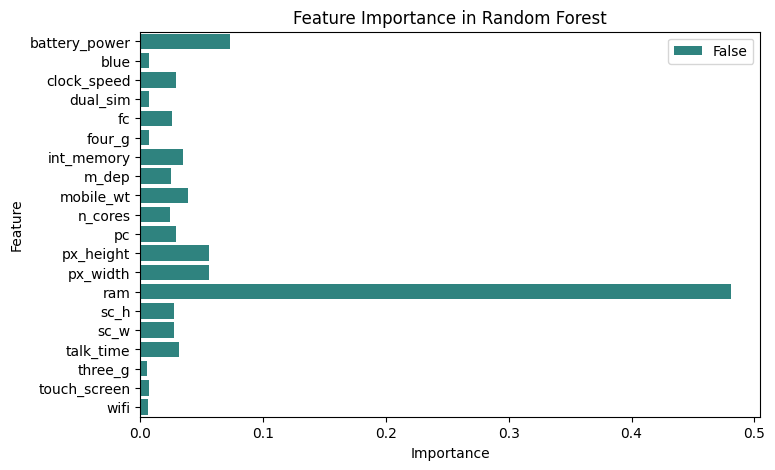

In [22]:
import seaborn as sns
importances = rfc.feature_importances_
features = X.columns
# Visualize
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features,hue=False ,palette='viridis')
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

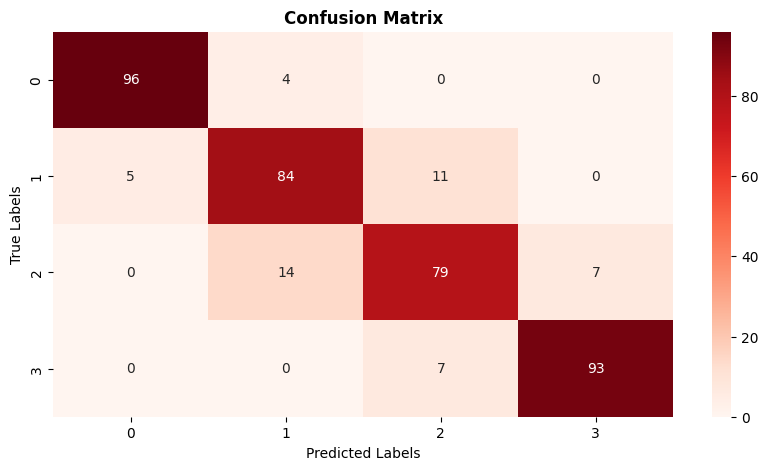

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix",fontweight='bold')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


<h2 style="color:blue", align='center'>Data Visualization in Actual vs Predicted </h2>

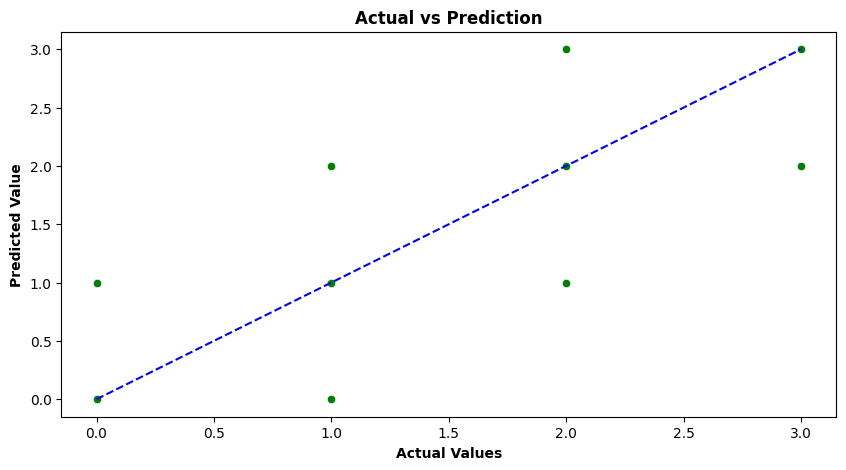

In [16]:
errors = y_test - y_pred
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_test, y=y_pred, color='green')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],"b--")
plt.title('Actual vs Prediction',fontweight='bold')
plt.xlabel('Actual Values',fontweight='bold')
plt.ylabel('Predicted Value',fontweight='bold')
plt.show()